# 02 — Análisis Exploratorio de Datos (EDA)

**Objetivo:** Explorar visualmente los datasets limpios para identificar
tendencias, patrones y relaciones entre variables climáticas.

## Preguntas que guían este análisis
1. ¿Cómo ha evolucionado la temperatura promedio global entre 2000 y 2024?
2. ¿Qué regiones muestran el calentamiento más acelerado?
3. ¿Existe relación entre CO₂ y temperaturas extremas?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Estilo visual consistente para todo el notebook
sns.set_theme(style='whitegrid', palette='coolwarm')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

# Rutas
from google.colab import drive
drive.mount('/content/drive')
ruta_clean = '/content/drive/MyDrive/Proyecto_Clima/ data/clean/'

# Cargamos datasets limpios
df_ind = pd.read_csv(ruta_clean + 'indicators_clean.csv')
df_global = pd.read_csv(ruta_clean + 'temp_global_clean.csv', parse_dates=['date'])
df_regions = pd.read_csv(ruta_clean + 'temp_regions_clean.csv', parse_dates=['date'] if 'date' in pd.read_csv(ruta_clean + 'temp_regions_clean.csv', nrows=1).columns else False)
df_co2 = pd.read_csv(ruta_clean + 'co2_clean.csv')

print("✅ Datos cargados")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Datos cargados


In [ ]:
# Carpeta para gráficos
import os
ruta_plots = '/content/drive/MyDrive/Proyecto_Clima/plots/'
os.makedirs(ruta_plots, exist_ok=True)
print("✅ Carpeta plots creada")

✅ Carpeta plots creada


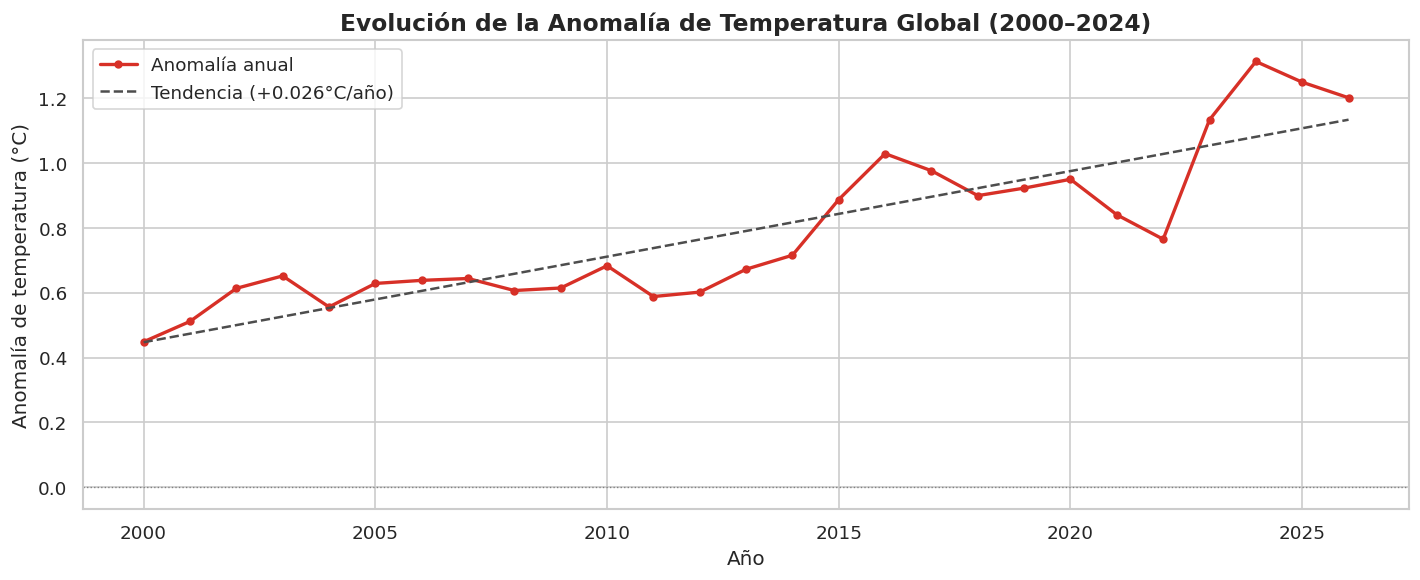

In [ ]:
# TENDENCIA DE TEMPERATURA GLOBAL - ANUAL

# Promedio anual de anomalía de temperatura global
temp_anual = df_global.groupby('year')['temp_anomaly_c'].mean().reset_index()

fig, ax = plt.subplots()

# Línea principal
ax.plot(temp_anual['year'], temp_anual['temp_anomaly_c'],
        color='#d73027', linewidth=2, marker='o', markersize=4, label='Anomalía anual')

# Línea de tendencia

z = np.polyfit(temp_anual['year'], temp_anual['temp_anomaly_c'], 1)
p = np.poly1d(z)
ax.plot(temp_anual['year'], p(temp_anual['year']),
        '--', color='#4d4d4d', linewidth=1.5, label=f'Tendencia (+{z[0]:.3f}°C/año)')

# Línea de referencia en cero
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')

ax.set_title('Evolución de la Anomalía de Temperatura Global (2000–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Anomalía de temperatura (°C)')
ax.legend()
plt.tight_layout()
plt.savefig(ruta_plots + 'plot_01_tendencia_global.png', dpi=150)
plt.show()

## Hallazgo 1 — Tendencia global de temperatura

La anomalía de temperatura global muestra una tendencia ascendente sostenida
de **+0.026°C por año** entre 2000 y 2024, acumulando aproximadamente **+0.65°C**
en 25 años respecto a la línea base 1951–1980.

Puntos notables:
- **2016**: pico anómalo asociado al evento El Niño más intenso registrado
- **2022**: caída temporal, posiblemente vinculada a La Niña
- **2023–2024**: los valores más altos de toda la serie

> La temperatura nunca regresó a valores cercanos a cero, confirmando que
> el calentamiento es una tendencia estructural, no una fluctuación temporal.

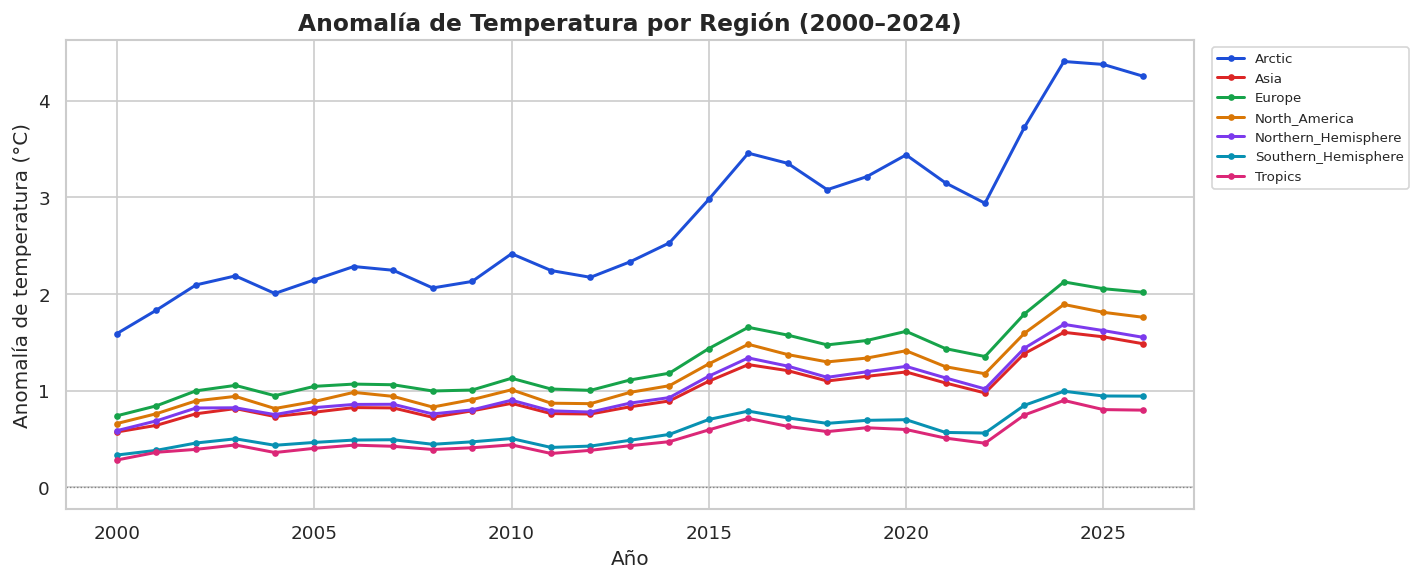

In [ ]:
# CALENTAMIENTO POR REGIÓN (2000–2024)

colores = {
    'Arctic': '#1d4ed8',         # azul fuerte
    'Asia': '#dc2626',           # rojo
    'Europe': '#16a34a',         # verde
    'North_America': '#d97706',  # naranja
    'Northern_Hemisphere': '#7c3aed',  # morado
    'Southern_Hemisphere': '#0891b2',  # cyan
    'Tropics': '#db2777'         # rosa
}

temp_region = df_regions.groupby(['year', 'region'])['temp_anomaly_c'].mean().reset_index()

fig, ax = plt.subplots()

for region in temp_region['region'].unique():
    data = temp_region[temp_region['region'] == region]
    ax.plot(data['year'], data['temp_anomaly_c'], linewidth=1.8, marker='o',
            markersize=3, label=region, color=colores.get(region, 'gray'))

ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.set_title('Anomalía de Temperatura por Región (2000–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Anomalía de temperatura (°C)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(ruta_plots + 'plot_02_calentamiento_regiones.png', dpi=150, bbox_inches='tight')
plt.show()

## Hallazgo 2 — Calentamiento por región

La gráfica revela diferencias dramáticas entre regiones:

- **Arctic** (azul): es la región con calentamiento más extremo, superando **+4.4°C**
  en 2024 — más del doble que cualquier otra región. Fenómeno conocido como
  *Arctic Amplification*.
- **Asia y Europe** (rojo y verde): muestran aceleración notable a partir de 2015,
  superando +2°C en años recientes.
- **Southern_Hemisphere y Tropics** (cyan y rosa): las regiones con menor anomalía,
  manteniéndose por debajo de +1°C la mayor parte del período.

> Ninguna región muestra enfriamiento o estabilización — todas tienen tendencia
> ascendente, con el Ártico como caso más crítico.

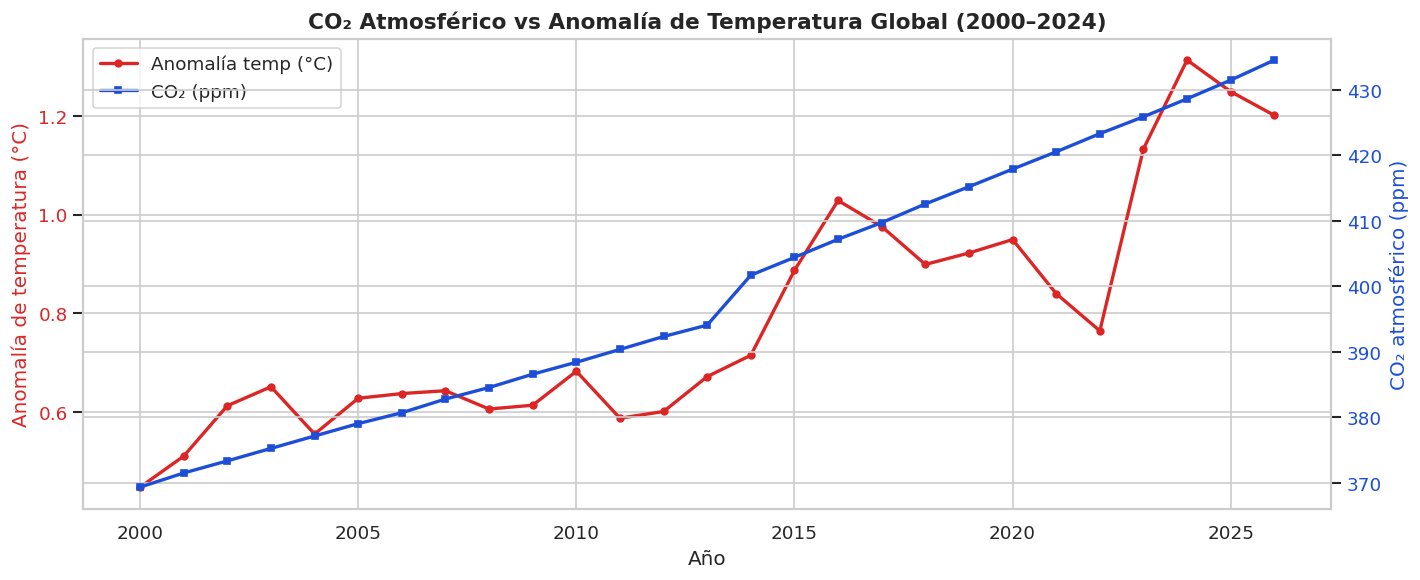

In [ ]:
# RELACIÓN CO₂ vs TEMPERATURA GLOBAL

# Promedio anual de co2_ppm y temp_anomaly desde df_global
co2_temp = df_global.groupby('year')[['temp_anomaly_c', 'co2_ppm']].mean().reset_index()

fig, ax1 = plt.subplots()

# Eje izquierdo — temperatura
ax1.plot(co2_temp['year'], co2_temp['temp_anomaly_c'],
         color='#dc2626', linewidth=2, marker='o', markersize=4, label='Anomalía temp (°C)')
ax1.set_xlabel('Año')
ax1.set_ylabel('Anomalía de temperatura (°C)', color='#dc2626')
ax1.tick_params(axis='y', labelcolor='#dc2626')

# Eje derecho — CO₂
ax2 = ax1.twinx()
ax2.plot(co2_temp['year'], co2_temp['co2_ppm'],
         color='#1d4ed8', linewidth=2, marker='s', markersize=4, label='CO₂ (ppm)')
ax2.set_ylabel('CO₂ atmosférico (ppm)', color='#1d4ed8')
ax2.tick_params(axis='y', labelcolor='#1d4ed8')

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('CO₂ Atmosférico vs Anomalía de Temperatura Global (2000–2024)',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(ruta_plots + 'plot_03_co2_vs_temperatura.png', dpi=150)
plt.show()

In [ ]:

r, p_value = stats.pearsonr(co2_temp['co2_ppm'], co2_temp['temp_anomaly_c'])

print(f"Correlación de Pearson (r): {r:.4f}")
print(f"P-value:                    {p_value:.6f}")
print()
if p_value < 0.05:
    print(f"✅ Correlación estadísticamente significativa (p < 0.05)")
else:
    print(f"⚠️ Correlación NO significativa (p >= 0.05)")
print()
print(f"Interpretación: el {r**2*100:.1f}% de la variación en temperatura")
print(f"es explicada linealmente por el nivel de CO₂")

Correlación de Pearson (r): 0.9004
P-value:                    0.000000

✅ Correlación estadísticamente significativa (p < 0.05)

Interpretación: el 81.1% de la variación en temperatura
es explicada linealmente por el nivel de CO₂


## Hallazgo 3 — Correlación CO₂ vs Temperatura

La correlación de Pearson entre el CO₂ atmosférico y la anomalía de temperatura
global es **r = 0.90**, con un p-value prácticamente cero.

Esto significa:
- **r = 0.90**: correlación positiva muy fuerte — cuando el CO₂ sube,
  la temperatura sube con él
- **p < 0.05**: el resultado es estadísticamente significativo,
  no producto del azar
- **R² = 81.1%**: el nivel de CO₂ explica el 81% de la variación
  en temperatura observada en el período 2000–2024

> **Nota importante**: correlación no implica causalidad. Sin embargo,
> este resultado es consistente con la evidencia científica consolidada
> que sí establece una relación causal entre emisiones de CO₂ y
> calentamiento global.

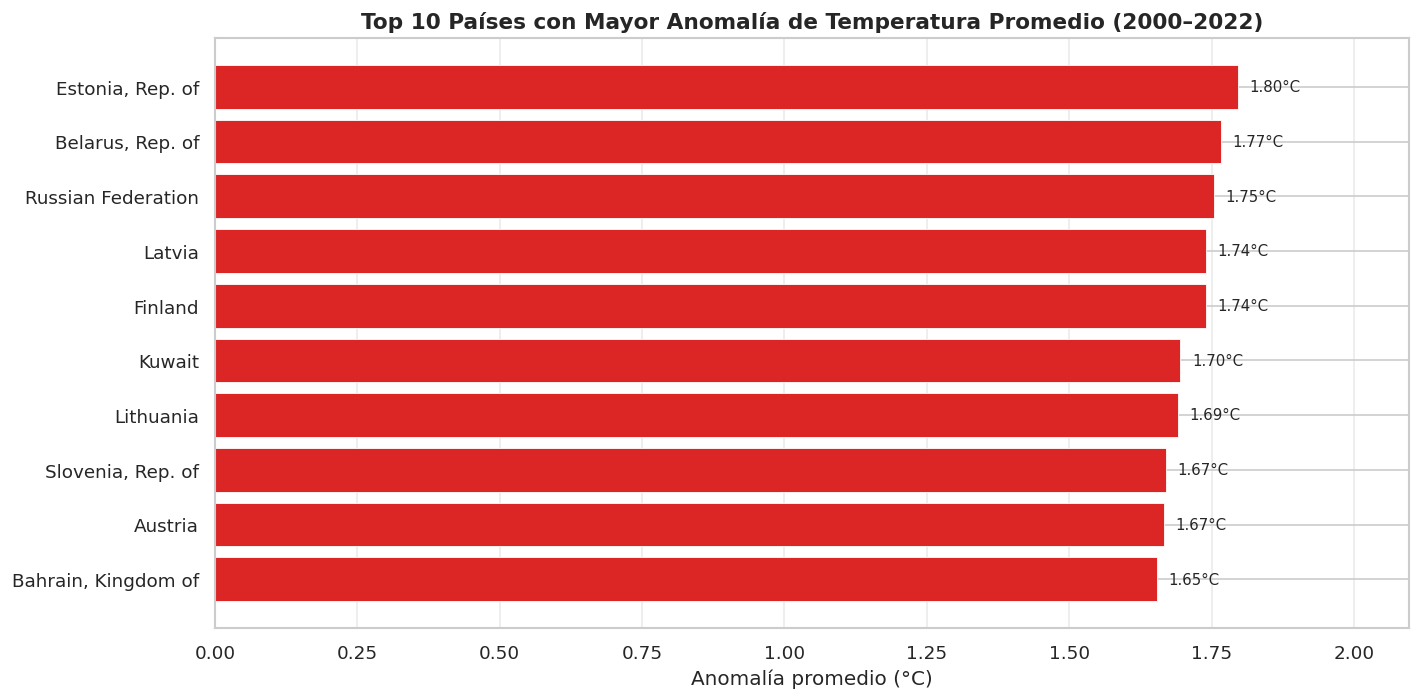

In [ ]:
# TOP 10 PAÍSES CON MAYOR CALENTAMIENTO PROMEDIO (2000–2022)

# Excluir 'World' y calcular promedio por país
top_paises = (df_ind[df_ind['Country'] != 'World']
              .groupby('Country')['Value']
              .mean()
              .sort_values(ascending=False)
              .head(10)
              .reset_index())

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(top_paises['Country'], top_paises['Value'],
               color='#dc2626', edgecolor='white', linewidth=0.5)

# Etiquetas de valor al final de cada barra
for bar, val in zip(bars, top_paises['Value']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}°C', va='center', fontsize=9)

ax.invert_yaxis()
ax.set_title('Top 10 Países con Mayor Anomalía de Temperatura Promedio (2000–2022)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Anomalía promedio (°C)')
ax.set_xlim(0, top_paises['Value'].max() + 0.3)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig(ruta_plots + 'plot_04_top10_paises.png', dpi=150)
plt.show()

## Hallazgo 4 — Top 10 países con mayor calentamiento

Los países con mayor anomalía de temperatura promedio (2000–2022) son
predominantemente del **norte de Europa y Asia Central**, con Estonia
liderando en **+1.80°C**, seguido de Belarus (+1.77°C) y Rusia (+1.75°C).

Patrones notables:
- **7 de los 10 países** pertenecen al norte de Europa (Estonia, Belarus,
  Latvia, Finland, Lithuania, Slovenia, Austria) — consistente con el
  hallazgo regional donde el Ártico y Europa muestran mayor calentamiento
- **Kuwait y Bahrain** son los únicos países de Medio Oriente en el top 10,
  representando una segunda zona crítica de calentamiento
- Todos los países superan **+1.65°C** de anomalía promedio — muy por encima
  de la media global de ~0.85°C en el mismo período

> Este hallazgo complementa el análisis regional: el calentamiento no es
> uniforme — las zonas de latitudes altas y algunas regiones áridas
> concentran los mayores incrementos.